## Load Test and Validation video in the folders

In [1]:
import os
import numpy as np
import pandas as pd
import librosa

test_folder = 'micro_medlydb/test/'
val_folder = 'micro_medlydb/validate/'

In [2]:
test_audio = [librosa.load((test_folder + file), mono=True, sr=22050)[0] for file in os.listdir(test_folder)]
val_audio = [librosa.load((val_folder + file), mono=True, sr=22050)[0] for file in os.listdir(val_folder)]

## Compute mean spectral flux and  mean MFCCs of all frames in all files
```text
psy code:Create compute features(audio_list):
            set flux and mfcc features
            for each audio signal in audio list:
               compute flux across time frames
               store
               compute mfcc
               store
            concatenate all flux sequeces across all pieces
            calculate mean and sd
            concatenate all mfcc matrices 
            calculate sd and mfcc coefficient
            return all flux means, all flux sd, all mfcc means and mfcc sd
···


In [3]:
sr = 22050
frame_size = 1024
hop = 512

def compute_all_frames(audio_list):
    all_flux=[]
    all_mfcc=[]

    for y in audio_list:
        prev_spec = None
        flux_seq = []
        window = np.hanning(frame_size)
        for start in range(0, len(y)-frame_size, hop):
            frame = y[start:start+frame_size] * window
            spectrum = np.abs(np.fft.rfft(frame))
            spec_n = spectrum / (np.linalg.norm(spectrum) + 1e-12)
            if prev_spec is not None:
                flux_seq.append(np.linalg.norm(spec_n - prev_spec))
            prev_spec = spec_n
        if flux_seq:
            all_flux.append(np.array(flux_seq))
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=10, hop_length=hop)
        if mfcc.size:
            all_mfcc.append(mfcc)

    all_flux=np.concatenate(all_flux,axis=0)
    all_flux_mean=np.mean(all_flux)
    all_flux_std=np.std(all_flux) + 1e-12

    all_mfcc=np.concatenate(all_mfcc, axis=1)
    all_mfcc_mean=np.mean(all_mfcc, axis=1)
    all_mfcc_std = np.std(all_mfcc, axis=1) + 1e-12
    return all_flux_mean, all_flux_std, all_mfcc_mean, all_mfcc_std


In [4]:
all_flux_mean, all_flux_std, all_mfcc_mean, all_mfcc_std=compute_all_frames(val_audio)

## Extract Text and Validation Audio Features
```
psy code: Create get feature function:
              initialize centroids, rolloffs, spreads, flatness, and fluxes
        for each frame in audio
             apply window
             calculate spectrum and bins
             calculate centroid, rolloff, spread, and flatness
             if prev_spec exists:
            compute flux as distance between current spectrum and previous spectrum
            else:
               flux = 0
               store flux
               update prev_spec
               store centroid, rolloff, spread, flatness
        compute zero crossing rate (zcr) over audio
        compute MFCCs (10 coefficients)
        normalize flux  using all_flux_mean, and all_flux_std
        normalize MFCCs using all_mfcc_mean, and all_mfcc_std
        aggregate by mean:
               centroid_mean, rolloff_mean, spread_mean, flatness_mean
               zcr_mean, flux_mean
                mfcc_1_mean ... mfcc_10_mean

    return dictionary of aggregated features
```
             

In [5]:
def get_features(audio, aggregate=True, sr=22050, frame_size=1024, hop=512):
    window = np.hanning(frame_size)
    frame = audio[0:frame_size] * window

    centroids = []
    rolloffs = []
    spreads = []
    flatnesses = []
    fluxes = []
    prev_spec = None

    for start in range(0, len(audio) - frame_size, hop):
        frame = audio[start:start+frame_size] * window
        spectrum = np.abs(np.fft.rfft(frame))
        freqs = np.fft.rfftfreq(frame_size, 1/sr)

        #centroid
        c = np.sum(freqs * spectrum) / (np.sum(spectrum) + 1e-12)
        #rolloff
        r_thresh = 0.85 * np.sum(spectrum)
        r_idx = np.searchsorted(np.cumsum(spectrum), r_thresh)
        r = freqs[min(r_idx, len(freqs) - 1)]
        #spread
        s = np.sqrt(np.sum(((freqs - c)**2) * spectrum) / (np.sum(spectrum) + 1e-12))
        #flatness
        f = np.exp(np.mean(np.log(spectrum + 1e-12))) / (np.mean(spectrum) + 1e-12)

        #flux
        if prev_spec is None:
            fluxes.append(0.0)
        else:
            mag_n = spectrum / (np.linalg.norm(spectrum) + 1e-12)
            prev_n = prev_spec / (np.linalg.norm(prev_spec) + 1e-12)
            fluxes.append(np.linalg.norm(mag_n - prev_n))
        prev_spec = spectrum

        centroids.append(c)
        rolloffs.append(r)
        spreads.append(s)
        flatnesses.append(f)

    #zcr
    zcrs = librosa.feature.zero_crossing_rate(y=audio, frame_length=frame_size, hop_length=hop, center=False)[0]

    #mfcc
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=10, hop_length=hop)
    fluxes = np.array(fluxes, dtype=float)
    flux_n=(fluxes-all_flux_mean)/(all_flux_std+1e-12)
    mfcc_n= (mfcc - all_mfcc_mean[:, None]) / (all_mfcc_std[:, None] + 1e-12)

    features = {
     "centroid_mean": np.mean(centroids),
     "rolloff_mean": np.mean(rolloffs),
     "spread_mean": np.mean(spreads),
     "flatness_mean": np.mean(flatnesses),
     "zcr_mean": np.mean(zcrs[:len(centroids)]),
     "flux_mean": np.mean(flux_n),
    }
    mfcc_means = mfcc_n.mean(axis=1)
    for i in range(10):
        features[f"mfcc_{i+1}_mean"] = mfcc_means[i]


    return features

## Aggregate All Features in Dateaframe

In [6]:
label = {3: "flute", 4: "piano", 6: "trumpet", 7: "violin"}

val_features=[]
for fname, clip in zip(os.listdir(val_folder), val_audio):
    dic = get_features(clip, sr=22050)   
    dic["track"] = fname                 
    dic["label_id"] = int(fname.split("-")[3].split("_")[0])       
    dic["label_name"] = label[dic["label_id"]]     
    val_features.append(dic)
val_df = pd.DataFrame(val_features)


test_features=[]
for fname, clip in zip(os.listdir(test_folder), test_audio):
    dic = get_features(clip, sr=22050)   
    dic["track"] = fname                 
    dic["label_id"] = int(fname.split("-")[3].split("_")[0])      
    dic["label_name"] = label[dic["label_id"]]     
    test_features.append(dic)
test_df = pd.DataFrame(test_features)


##  Across-feature normalization

In [7]:
norm_val_df= val_df.copy()
norm_test_df = test_df.copy()
feature_cols = [c for c in val_df.columns if c not in ["track", "label_id", "label_name"]]

mu = val_df[feature_cols].mean()
sd = val_df[feature_cols].std() + 1e-12  

norm_val_df[feature_cols]  = (val_df[feature_cols]  - mu) / sd
norm_test_df[feature_cols] = (test_df[feature_cols] - mu) / sd
print(norm_val_df)
print(norm_test_df)
norm_val_df.to_csv("norm_val_df.csv", index=False)
norm_test_df.to_csv("norm_test_df.csv", index=False)

     centroid_mean  rolloff_mean  spread_mean  flatness_mean  zcr_mean  \
0         0.177665     -0.279176    -0.063907      -0.486974  0.072898   
1        -1.549442     -1.457614    -1.777124       3.163936 -1.228173   
2         0.858729      0.790120     0.784948       0.257330  0.752641   
3        -0.170459     -0.231535     0.332834       0.196219 -0.630495   
4        -0.385357     -0.561875    -0.868044      -0.746931 -0.255504   
..             ...           ...          ...            ...       ...   
115       0.934867      0.866531     0.743057      -0.105903  1.319544   
116       0.728154      0.902058     0.840063       0.932045 -0.291978   
117      -0.285145     -0.608118    -0.435445      -0.683661 -0.285139   
118      -0.210250     -0.636190    -0.289461      -0.487220 -0.217749   
119      -0.198567     -0.204977    -0.160336      -0.030226 -0.387720   

     flux_mean  mfcc_1_mean  mfcc_2_mean  mfcc_3_mean  mfcc_4_mean  \
0    -2.088215     0.146011    -1.142426 

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Correlation Matrix, Highly and Weakly Correlated Features

               centroid_mean  rolloff_mean  spread_mean  flatness_mean  \
centroid_mean       1.000000      0.975946     0.881577       0.328636   
rolloff_mean        0.975946      1.000000     0.926462       0.385657   
spread_mean         0.881577      0.926462     1.000000       0.381830   
flatness_mean       0.328636      0.385657     0.381830       1.000000   
zcr_mean            0.921586      0.872357     0.715313       0.242961   
flux_mean           0.639231      0.670975     0.638012       0.125098   
mfcc_1_mean        -0.226446     -0.332929    -0.449915      -0.418898   
mfcc_2_mean        -0.804257     -0.757651    -0.757518      -0.452327   
mfcc_3_mean        -0.038977      0.087467     0.226409       0.198829   
mfcc_4_mean         0.279295      0.386202     0.429326      -0.006628   
mfcc_5_mean        -0.382270     -0.285012    -0.181196      -0.027907   
mfcc_6_mean         0.161471      0.148609     0.256291       0.209712   
mfcc_7_mean         0.124977      0.13

<Figure size 1000x400 with 0 Axes>

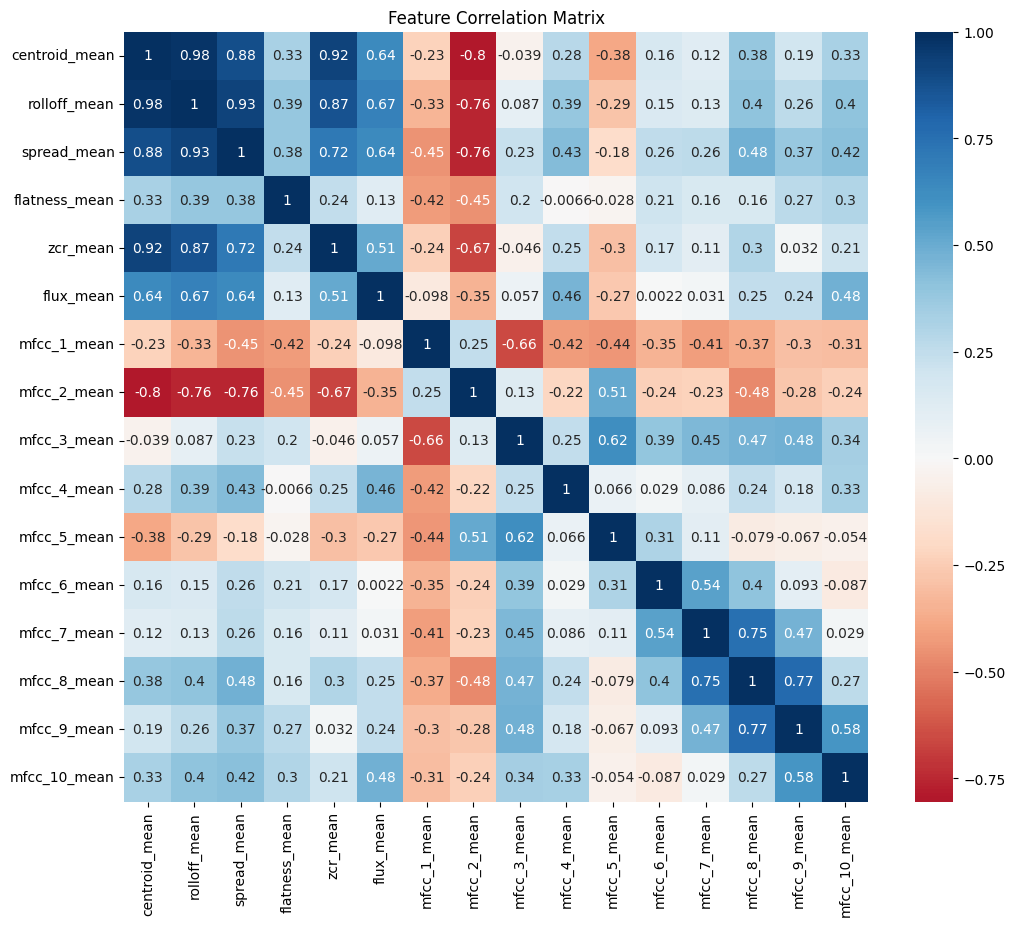

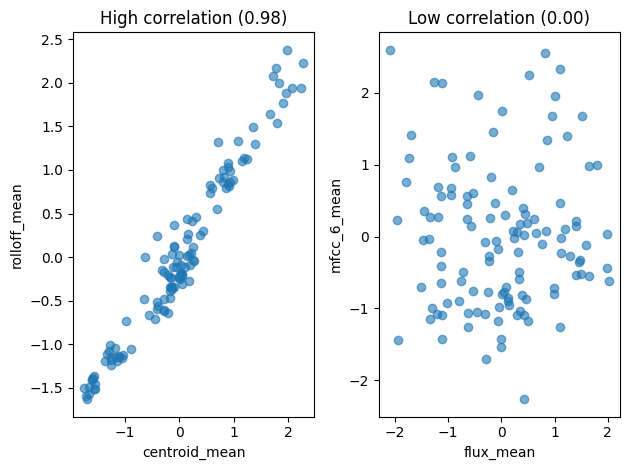

In [9]:
features_df = norm_val_df.drop(columns=["track", "label_id", "label_name"])


correlation = features_df.corr()
correlation_matrix = features_df.corr(method="pearson")
print(correlation_matrix)
correlation_matrix.to_csv("correlation_matrix.csv", index=True)

correlation_values = correlation.abs().unstack()   
correlation_values = correlation_values[correlation_values< 0.9999]  
max_p = correlation_values.idxmax()
min_p = correlation_values.idxmin()



plt.figure(figsize=(10,4))

plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix , cmap="RdBu", center=0, annot=True)
plt.title("Feature Correlation Matrix")
plt.savefig("Feature Correlation Matrix.png")
plt.show()


plt.subplot(1,2,1)
plt.scatter(features_df[max_p[0]], features_df[max_p[1]], alpha=0.6)
plt.xlabel(max_p[0])
plt.ylabel(max_p[1])
plt.title(f"High correlation ({correlation[max_p[0]][max_p[1]]:.2f})")


plt.subplot(1,2,2)
plt.scatter(features_df[min_p[0]], features_df[min_p[1]], alpha=0.6)
plt.xlabel(min_p[0])
plt.ylabel(min_p[1])
plt.title(f"Low correlation ({correlation[min_p[0]][min_p[1]]:.2f})")

plt.tight_layout()
plt.savefig("High_and_Low_correlation.png")
plt.show()


## Classification

k=3  (val accuracy = 1.000)
k=5  (val accuracy = 0.992)
k=7  (val accuracy = 0.983)
k=9  (val accuracy = 0.975)
k=11  (val accuracy = 0.967)
k=13  (val accuracy = 0.958)
k=15  (val accuracy = 0.942)
Test Accuracy: 0.6


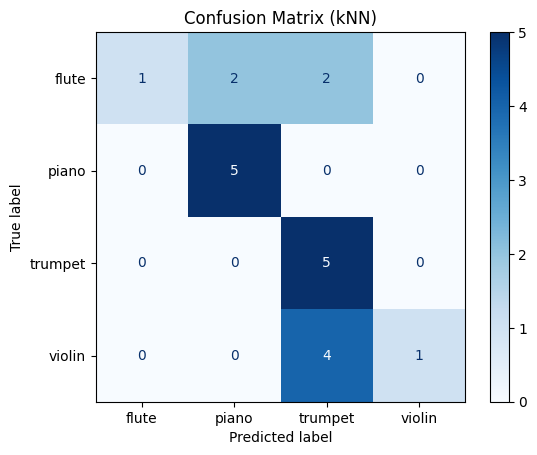

In [10]:
x_val =norm_val_df.drop(columns=["track", "label_id", "label_name"])
y_val = norm_val_df["label_id"].values

x_test = norm_test_df.drop(columns=["track", "label_id", "label_name"])
y_test = norm_test_df["label_id"].values



for k in [3,5,7,9,11,13,15]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(x_val, y_val)
    print(f"k={k}  (val accuracy = {knn.score(x_val, y_val):.3f})")

y_pred = knn.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

c_matrix=confusion_matrix(y_test, y_pred, labels=[3,4,6,7])
disply = ConfusionMatrixDisplay(confusion_matrix=c_matrix, display_labels=["flute","piano","trumpet","violin"])

disply.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (kNN)")
plt.savefig("Confusion Matrix (kNN).png")
plt.show()

## PCA&Classification

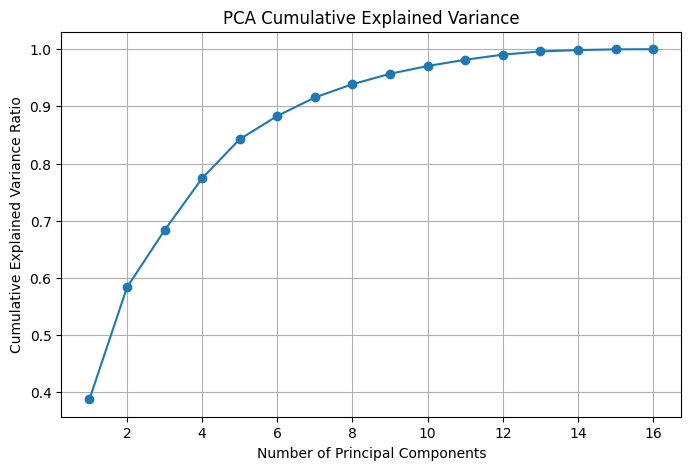


Using 5 principal components:
k=3  (val accuracy = 1.000, test accuracy = 0.600)
k=5  (val accuracy = 0.992, test accuracy = 0.600)
k=7  (val accuracy = 0.975, test accuracy = 0.600)
k=9  (val accuracy = 0.950, test accuracy = 0.600)
k=11  (val accuracy = 0.950, test accuracy = 0.600)
k=13  (val accuracy = 0.917, test accuracy = 0.650)
k=15  (val accuracy = 0.908, test accuracy = 0.650)


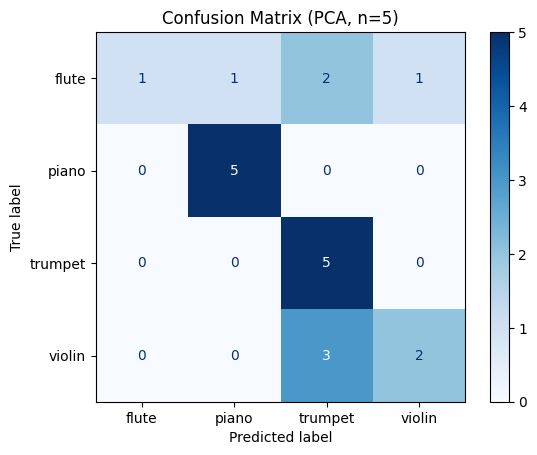

In [30]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# from Feature_Classification_Part1 import norm_val_df, norm_test_df


# Data from our classification hw1, which called "Feature_Classification_Part1"
X_val = norm_val_df.drop(columns=["track", "label_id", "label_name"]).values
y_val = norm_val_df["label_id"].values
X_test = norm_test_df.drop(columns=["track", "label_id", "label_name"]).values
y_test = norm_test_df["label_id"].values


# PCA Cumulative Explained Variance 
pca_test = PCA()
pca_test.fit(X_val)
CEV= pca_test.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(CEV) + 1), CEV, marker='o', linestyle='-')
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()


# pca+knn
n_components = 5   
pca = PCA(n_components=n_components)
X_val_pca = pca.fit_transform(X_val)
X_test_pca = pca.transform(X_test)

print(f"\nUsing {n_components} principal components:")

# k difference for validation
for k in [3,5,7,9,11,13,15]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_val_pca, y_val)
    y_pred = knn.predict(X_test_pca)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"k={k}  (val accuracy = {knn.score(X_val_pca, y_val):.3f}, test accuracy = {test_acc:.3f})")


# confusion_matrix for pca
c_matrix = confusion_matrix(y_test, y_pred, labels=[3, 4, 6, 7])
disp = ConfusionMatrixDisplay(confusion_matrix=c_matrix,
                              display_labels=["flute", "piano", "trumpet", "violin"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (PCA, n={n_components})")
plt.show()

### Writeup
a)
In order to evaluate how many principal components to keep, we used the cumulative explained variance. Looking at the cumulative sum of explained variance ratios in our plot, it can be observed that each additional principal component explains increasingly less of the variance. Using the "elbow" method, we select PC 5 as the cutoff, as following components contribute little to the cumulative explained variance ratio and we still keep enough PCs to explain about 85% of the variance.

b)
Our model performed the same as before, both resulting in a test accuracy of 60%. The "better" method depends on what the user is looking for. If interpretability is a key concern, using the original features may be the best option. However, PCA likely produces the most effective model. This is because the reduced dimensionality gives the same accuracy with less complexity, it removes redundancies, and helps to better generalize with limited training data by effectively removing the noise created by multicollinearity.